In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('/content/dry_bulk_freight_rates_SIH26006.csv')

df['date'] = pd.to_datetime(df['date'])

# Create route identifier
df['route'] = (
    df['origin_port'].astype(str) + '_' +
    df['destination_port'].astype(str) + '_' +
    df['vessel_class'].astype(str)
)

print("Shape:", df.shape)
print("Routes:", df['route'].nunique())
print("Date range:", df['date'].min(), "to", df['date'].max())

Shape: (255640, 6)
Routes: 140
Date range: 2021-01-01 00:00:00 to 2025-12-31 00:00:00


In [22]:
df = df.sort_values(['date', 'route']).reset_index(drop=True)

g = df.groupby('route')['freight_rate_usd_per_ton']

# Lag features
df['rate_lag1'] = g.shift(1)
df['rate_lag7'] = g.shift(7)
df['rate_lag30'] = g.shift(30)

# Rolling features using only past 7/30 days
df['rolling_mean_7'] = (
    g.shift(1)
     .transform(lambda x: x.rolling(7).mean())
)

df['rolling_std_7'] = (
    g.shift(1)
     .transform(lambda x: x.rolling(7).std())
)

df['rolling_mean_30'] = (
    g.shift(1)
     .transform(lambda x: x.rolling(30).mean())
)

# Historical percentage changes
df['pct_change_1'] = g.pct_change(1)
df['pct_change_7'] = g.pct_change(7)

# Calendar features
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

In [23]:
df['target'] = g.shift(-1)

# Remove rows with insufficient history / no tomorrow value
df = df.dropna().reset_index(drop=True)

print(df.shape)

print(
    df[
        ['route',
         'date',
         'freight_rate_usd_per_ton',
         'target']
    ].head(10)
)

(251300, 17)
                         route       date  freight_rate_usd_per_ton  target
0       Nacala_Dhamra_Capesize 2021-01-31                      5.33    5.36
1      Nacala_Dhamra_Handysize 2021-01-31                     12.70   12.46
2        Nacala_Dhamra_Panamax 2021-01-31                      8.10    7.59
3       Nacala_Dhamra_Supramax 2021-01-31                      9.57    9.81
4   Nacala_Gangavaram_Capesize 2021-01-31                      6.16    6.32
5  Nacala_Gangavaram_Handysize 2021-01-31                     12.89   12.86
6    Nacala_Gangavaram_Panamax 2021-01-31                      7.65    8.15
7   Nacala_Gangavaram_Supramax 2021-01-31                      9.66    9.74
8     Nacala_Gopalpur_Capesize 2021-01-31                      6.32    6.46
9    Nacala_Gopalpur_Handysize 2021-01-31                     12.13   12.10


In [24]:
feature_cols = [
    'rate_lag1',
    'rate_lag7',
    'rate_lag30',
    'rolling_mean_7',
    'rolling_std_7',
    'rolling_mean_30',
    'pct_change_1',
    'pct_change_7',
    'day_of_week',
    'month'
]

In [25]:
# 80% of the TIME period for training,
# 20% of the TIME period for testing

split_date = df['date'].quantile(0.80)

train = df[df['date'] <= split_date].copy()
test = df[df['date'] > split_date].copy()

X_train = train[feature_cols]
y_train = train['target']

X_test = test[feature_cols]
y_test = test['target']

print("Split date:", split_date)

print("\nTraining:")
print(train['date'].min(), "to", train['date'].max())
print("Rows:", len(train))

print("\nTesting:")
print(test['date'].min(), "to", test['date'].max())
print("Rows:", len(test))

Split date: 2025-01-05 04:48:00.000001024

Training:
2021-01-31 00:00:00 to 2025-01-05 00:00:00
Rows: 201040

Testing:
2025-01-06 00:00:00 to 2025-12-30 00:00:00
Rows: 50260


In [26]:
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [27]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"MAPE = {mape:.2f}%")

MAE  = 0.4223
RMSE = 0.6029
MAPE = 3.15%


rate_lag1          0.785637
rate_lag7          0.190724
rate_lag30         0.009578
pct_change_1       0.007469
pct_change_7       0.005368
rolling_mean_7     0.000527
month              0.000340
rolling_mean_30    0.000153
rolling_std_7      0.000112
day_of_week        0.000092
dtype: float32


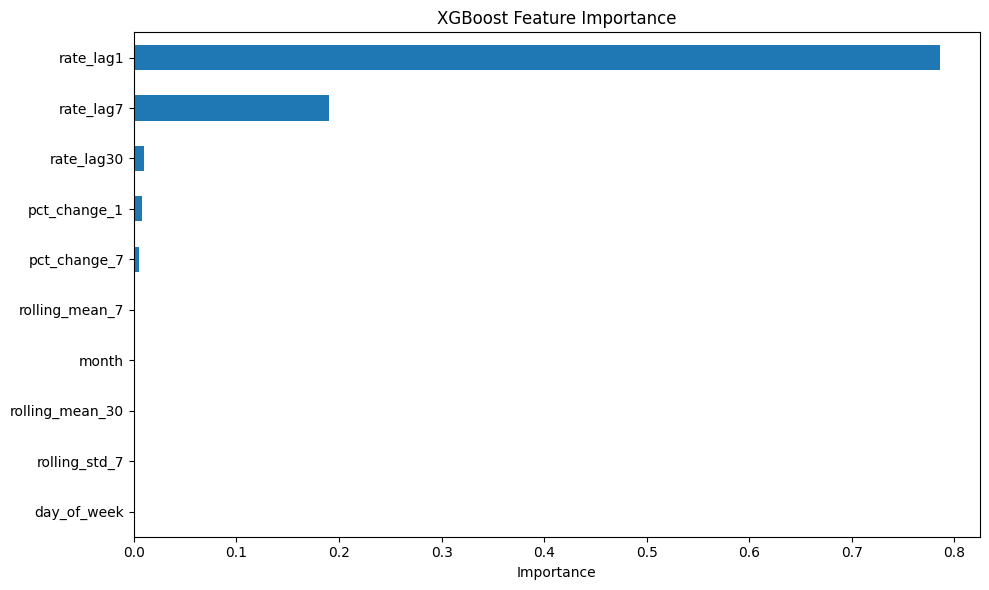

In [28]:
importances = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print(importances)

plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

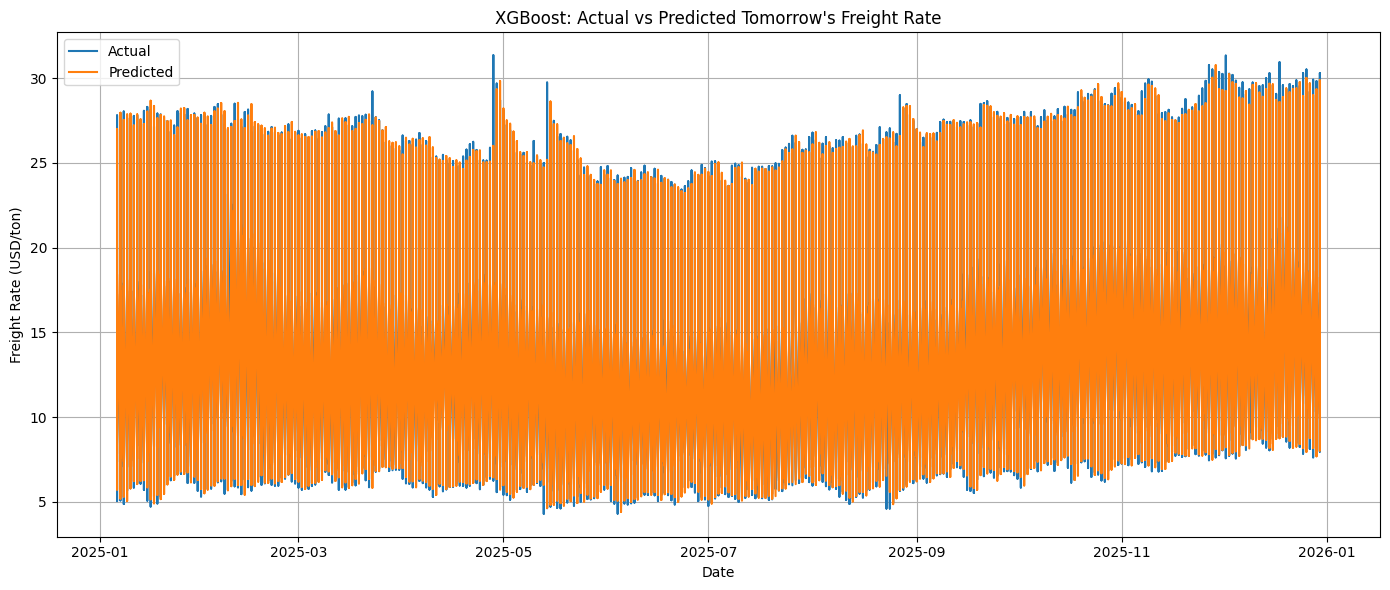

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(
    test['date'],
    y_test.values,
    label='Actual'
)

plt.plot(
    test['date'],
    pred,
    label='Predicted'
)

plt.title("XGBoost: Actual vs Predicted Tomorrow's Freight Rate")
plt.xlabel("Date")
plt.ylabel("Freight Rate (USD/ton)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
joblib.dump(model, '/content/freight_xgboost_model.pkl')
joblib.dump(feature_cols, '/content/feature_columns.pkl')

print("Model saved:")
print("/content/freight_xgboost_model.pkl")
print("/content/feature_columns.pkl")

Model saved:
/content/freight_xgboost_model.pkl
/content/feature_columns.pkl
